# Ejercicio k-Nearest Neighbor

## App Reviews
En este ejercicio vas a trabajar con una base de datos de reviews de una aplicación. Entre los datos podemos encontrar el texto de la review, las estrellas, así como el sentimiento del comentario (si es algo bueno o malo).

El objetivo es montar un algoritmo de clasificación que prediga el rating, en función del sentimiento del comentario y la cantidad de palabras empleadas en el mismo. Para ello tendrás que utilizar un algoritmo de tipo KNN.

## Importamos las librerías que vamos a utilizar

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [6]:
from sklearn.preprocessing import MinMaxScaler

## Leemos nuestro archivo de entrada `reviews_sentiment`

In [2]:
# Cargamos los datos
df = pd.read_csv('data/reviews_sentiment.csv', sep=';')

df.head()

,Review Title,Review Text,wordcount,titleSentiment,textSentiment,Star Rating,sentimentValue
0,Sin conexión,Hola desde hace algo más de un mes me pone sin...,23,negative,negative,1,-0.486389
1,faltan cosas,Han mejorado la apariencia pero no,20,negative,negative,1,-0.586187
2,Es muy buena lo recomiendo,Andres e puto amoooo,4,NaN,negative,1,-0.602240
3,Version antigua,Me gustana mas la version anterior esta es mas...,17,NaN,negative,1,-0.616271
4,Esta bien,Sin ser la biblia.... Esta bien,6,negative,negative,1,-0.651784


Para facilitar el ejercicio, las columnas que utilizaremos serán: wordcount con la cantidad de palabras utilizadas y sentimentValue con un valor entre -4 y 4 que indica si el comentario fue valorado como positivo o negativo

Nuestras etiquetas, serán las estrellas que dieron los usuarios a la app, que son valores discretos del 1 al 5

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Review Title    257 non-null    str    
 1   Review Text     257 non-null    str    
 2   wordcount       257 non-null    int64  
 3   titleSentiment  231 non-null    str    
 4   textSentiment   257 non-null    str    
 5   Star Rating     257 non-null    int64  
 6   sentimentValue  257 non-null    float64
dtypes: float64(1), int64(2), str(4)
memory usage: 14.2 KB


## Rápidas visualizaciones y análisis
Al menos realiza un análisis univariante y representa la distribución del rating. Realiza otras visualizaciones para ver la relación de tus datos.

In [3]:
df.describe()

,wordcount,Star Rating,sentimentValue
count,257.000000,257.000000,257.000000
mean,11.501946,3.420233,0.383849
std,13.159812,1.409531,0.897987
min,1.000000,1.000000,-2.276469
25%,3.000000,3.000000,-0.108144
50%,7.000000,3.000000,0.264091
75%,16.000000,5.000000,0.808384
max,103.000000,5.000000,3.264579


<Axes: xlabel='Star Rating', ylabel='Count'>

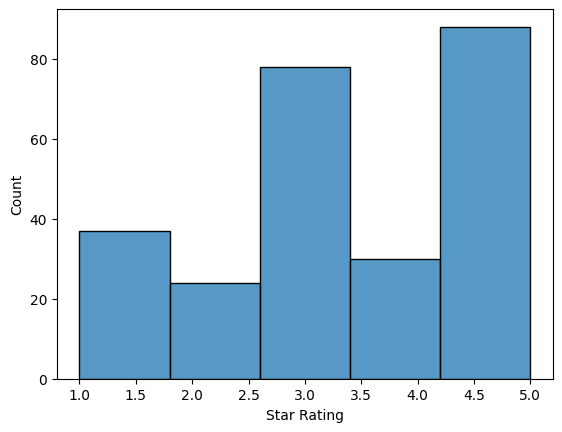

In [4]:
sns.histplot(data=df, x='Star Rating', bins=5)

## Preparamos el dataset
Divide en train/test y escala las features en el rango [0, 1].

In [7]:
X = df[['wordcount', 'sentimentValue']].values
y = df['Star Rating'].values

# Dividimos en entrenamiento (para que el modelo estudie) 
# y test (para examinarlo después)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = MinMaxScaler()
X_train_scal = scaler.fit_transform(X_train)
X_test_scal =scaler.transform (X_test)


## Creamos el Modelo
Entrena con un KNN y evalúa el error en train y en test

In [9]:
# Creamos el modelo con k a 7 (porque sí)
knn = KNeighborsClassifier(n_neighbors=7)

# Entrenamos
knn.fit(X_train_scal, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Evalúa tu modelo

In [11]:
# Predecimos
y_pred = knn.predict(X_test_scal)

c_matrix = confusion_matrix (y_test,y_pred)
print (c_matrix)
# Sacamos las notas del examen
print(classification_report(y_test, y_pred))

[[ 9  1  0  0  0]
 [ 0  2  0  0  0]
 [ 1  1 12  0  0]
 [ 0  1  1  2  3]
 [ 0  0  1  0 18]]
              precision    recall  f1-score   support

           1       0.90      0.90      0.90        10
           2       0.40      1.00      0.57         2
           3       0.86      0.86      0.86        14
           4       1.00      0.29      0.44         7
           5       0.86      0.95      0.90        19

    accuracy                           0.83        52
   macro avg       0.80      0.80      0.73        52
weighted avg       0.87      0.83      0.81        52



In [ ]:
#Dos y cuatro estrellas los predice peor. Tiene lógica porque eran bastante menos

## ¿Cómo obtener el mejor valor de k? Crea y evalúa nuevos modelos
¿Qué valor de k maximiza el accuracy? Representa todas las iteraciones en un scatterplot -> k vs accuracy

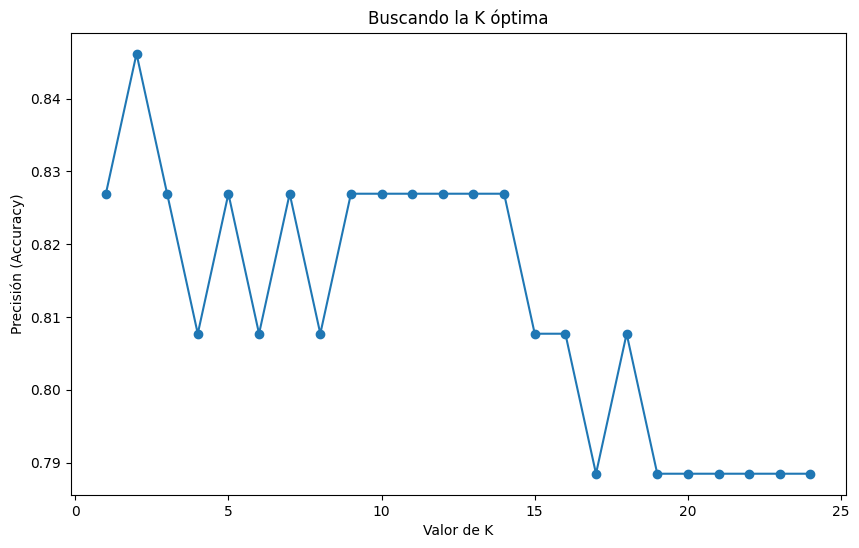

In [12]:
#Probamos ks de entre 1 hasta 25
k_range = range(1, 25)
scores = []

for k in k_range:
    knn_trial = KNeighborsClassifier(n_neighbors=k)
    knn_trial.fit(X_train_scal, y_train)
    scores.append(knn_trial.score(X_test_scal, y_test))

# Dibujamos el gráfico de "K vs Accuracy"
plt.figure(figsize=(10,6))
plt.scatter(k_range, scores)
plt.plot(k_range, scores)
plt.xlabel('Valor de K')
plt.ylabel('Precisión (Accuracy)')
plt.title('Buscando la K óptima')
plt.show()

In [ ]:
# Segun este gráfico el k óptimo sería  2

## Predice con nuevos datos.
Ejemplo: supongamos que nos llega una review de 5 palabras y sentimiento 1

In [16]:
# Creamos el nuevo dato: 5 palabras, sentimiento 1.0
nueva_review = np.array([[5, 1.0]])

#Uso el valor óptimo de k
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit (X_train_scal, y_train)

prediccion = knn.predict(nueva_review)
prediccion

array([2])

Predice 2 estrellas